In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()
rf = joblib.load('../backend/models/random_forest_model.pkl')

print("✅ Loaded")

c:\Users\Constantine\Desktop\FraudLens\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Loaded


In [2]:
# Cell 2 — Build SHAP explainer (takes 1-2 mins)
explainer = shap.TreeExplainer(rf)
print("✅ Explainer built")

✅ Explainer built


In [3]:
# Cell 3 — Get SHAP values for a small sample (100 rows)
sample = X_test.iloc[:100]
shap_values = explainer.shap_values(sample)
print("SHAP values shape:", np.array(shap_values).shape)

SHAP values shape: (100, 30, 2)


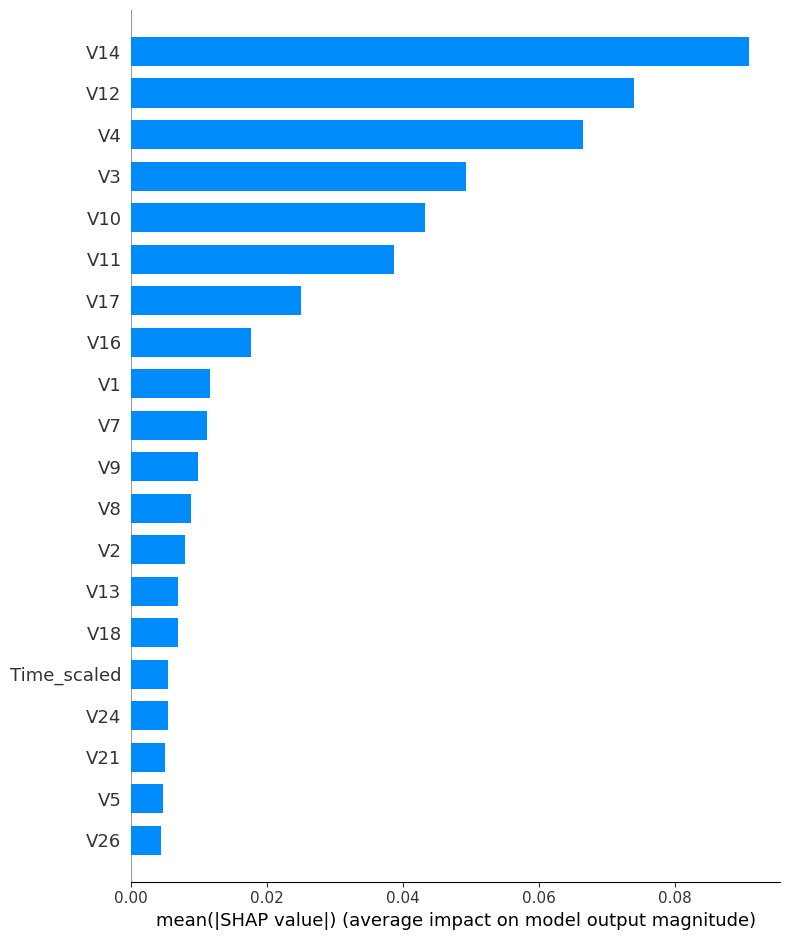

In [4]:
# Cell 4 — Summary plot (global feature importance)
shap.summary_plot(
    shap_values[:, :, 1],
    sample,
    plot_type="bar",
    show=True
)

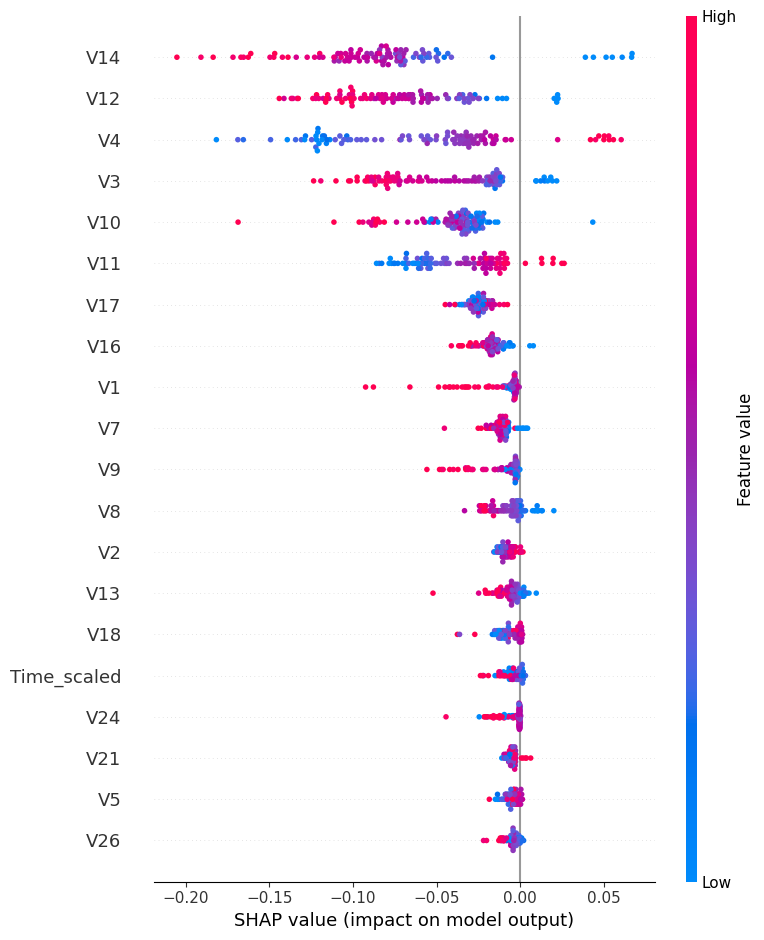

In [5]:
# Cell 5 — Detailed summary plot
shap.summary_plot(
    shap_values[:, :, 1],
    sample,
    show=True
)

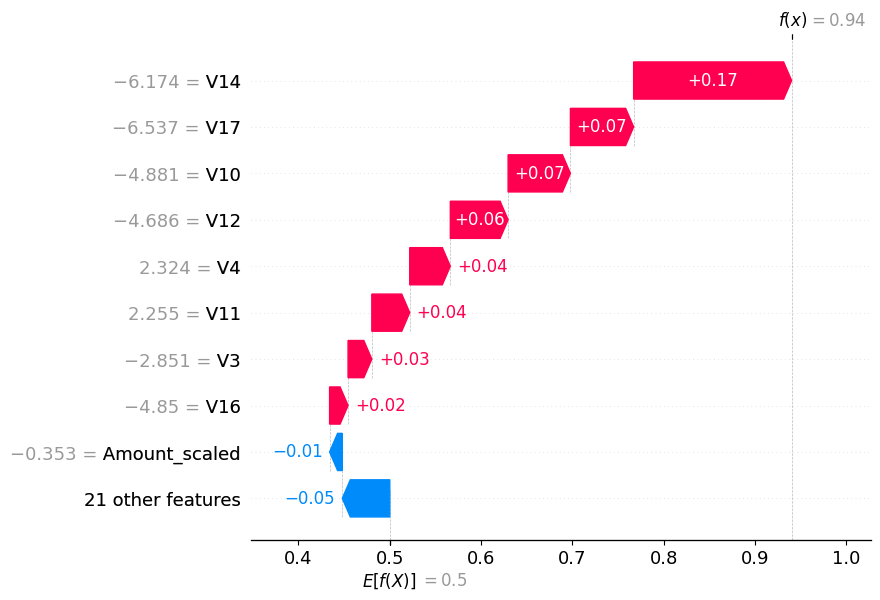

In [6]:
# Cell 6 — Explain a single fraud transaction
fraud_indices = np.where(y_test == 1)[0]
sample_idx = fraud_indices[0]
transaction = X_test.iloc[[sample_idx]]

shap_single = explainer.shap_values(transaction)

shap.waterfall_plot(
    shap.Explanation(
        values=shap_single[:, :, 1][0],
        base_values=explainer.expected_value[1],
        data=transaction.iloc[0],
        feature_names=X_test.columns.tolist()
    )
)